## Load the celebA Dataset

In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the same transforms as before
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # RGB → 1 channel
    transforms.Resize((64, 64)),                 # Resize to 64x64
    transforms.ToTensor()                        # Convert to [0, 1] tensor
])

# 2. Point to the ROOT directory
# Note: root should contain a sub-folder (e.g., 'img_align_celeba') 
# that holds the .jpg files.
root_path = "../data/celeba" 

dataset = datasets.ImageFolder(
    root=root_path,
    transform=transform
)

# 3. Create the Loader
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Sanity check: Print number of images
print(f"Total images loaded: {len(dataset)}")

Total images loaded: 23429


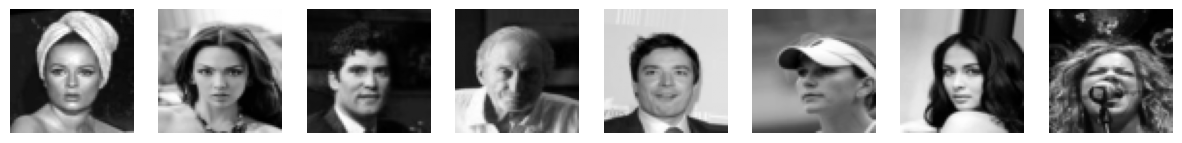

In [2]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0), cmap = "grey")
    axes[i].axis("off")

plt.show()

## Model Building

In [3]:
import torch
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F


import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        # Layer 1: 64 -> 32
        self.conv1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Layer 2: 32 -> 16
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Layer 3: 16 -> 8
        self.conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(256)

        # Layer 4: 8 -> 4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(512)

        self.flatten = nn.Flatten()
        
        # Flattened size is 512 * 4 * 4 = 8192
        self.fc_mean = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = F.relu(self.bn2(self.conv2(h)))
        h = F.relu(self.bn3(self.conv3(h)))
        h = F.relu(self.bn4(self.conv4(h))) # Added forward for layer 4

        h = self.flatten(h)
        mu = self.fc_mean(h)
        log_var = self.fc_logvar(h)
        return mu, log_var
    
    def reparameterization(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        return mu + eps * std

class CNNDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        # Start from 4x4 bottleneck
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        
        # Layer 1: 4 -> 8
        self.deconv1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        
        # Layer 2: 8 -> 16
        self.deconv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Layer 3: 16 -> 32
        self.deconv3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Layer 4: 32 -> 64
        self.deconv4 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 512, 4, 4)
        
        h = F.relu(self.bn1(self.deconv1(h)))
        h = F.relu(self.bn2(self.deconv2(h)))
        h = F.relu(self.bn3(self.deconv3(h)))
        
        return torch.sigmoid(self.deconv4(h))

class CNNVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = CNNEncoder(latent_dim)
        self.decoder = CNNDecoder(latent_dim)
    
    def forward(self, x: torch.tensor):
        mean, log_var = self.encoder(x)
        z = self.encoder.reparameterization(mean, log_var)
        logits = self.decoder(z)
        return (mean, log_var), logits
    
    def kl_divergence(self, mu: torch.tensor, log_var: torch.tensor):
        return -0.5 * torch.sum(1 + log_var - torch.exp(log_var) - mu.pow(2), dim=-1)

def train_vae_model(model, loader, epochs, optimizer, device, anneal_epochs=40):
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        total_recon_loss = 0
        total_kl_loss = 0
        
        # Beta annealing for KL Divergence
        beta = min(1.0, epoch / anneal_epochs)
        
        # tqdm setup with a description
        batch_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for images, _ in batch_bar:
            x = images.to(device)

            # Forward pass
            (mean, log_var), reconstructed_x = model(x)
            
            # 1. Reconstruction Loss (Binary Cross Entropy)
            # Use F.binary_cross_entropy if you added Sigmoid to the decoder
            recon_loss = F.binary_cross_entropy(reconstructed_x, x, reduction="mean")
            
            # 2. KL Divergence Loss
            kl_val = model.kl_divergence(mean, log_var)
            kl_loss = torch.mean(kl_val)

            # Combined Loss with scaling (Adjust 0.001 based on performance)
            combined_loss = recon_loss + (kl_loss * beta * 0.0001)

            # Backward pass
            optimizer.zero_grad()
            combined_loss.backward()
            optimizer.step()

            # Stats for logging
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()

            # Update tqdm bar with both losses
            batch_bar.set_postfix({
                "Recon": f"{recon_loss.item():.4f}",
                "KL": f"{kl_loss.item():.4f}",
                "Beta": f"{beta:.2f}"
            })

        avg_recon = total_recon_loss / len(loader)
        avg_kl = total_kl_loss / len(loader)
        
        print(f"==> Epoch {epoch} Complete | Avg Recon: {avg_recon:.4f} | Avg KL: {avg_kl:.4f}")

    return model

## Model Traning

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
in_features = images[0].shape[-1] * images[0].shape[-1]
out_features = images[0].shape[-1] * images[0].shape[-1]
latent_dim = 64
lr = 2e-4
vae = CNNVAE(latent_dim)
optimizer = torch.optim.Adam(params = vae.parameters(), lr = lr)

print(f"Training on device: [{device}]")
trained_vae = train_vae_model(
    model = vae,
    loader = loader,
    epochs = 200,
    optimizer = optimizer,
    device = device
)

Training on device: [cuda]


Epoch 1/200: 100%|██████████| 367/367 [02:42<00:00,  2.26it/s, Recon=0.5310, KL=456.9037, Beta=0.00]           


==> Epoch 0 Complete | Avg Recon: 0.5741 | Avg KL: 2087684952588.8328


Epoch 2/200: 100%|██████████| 367/367 [00:30<00:00, 12.15it/s, Recon=0.4877, KL=302.9373, Beta=0.03]


==> Epoch 1 Complete | Avg Recon: 0.5281 | Avg KL: 312.2473


...

Epoch 67/200: 100%|██████████| 367/367 [00:34<00:00, 10.77it/s, Recon=0.5787, KL=116.9548, Beta=1.00]


==> Epoch 66 Complete | Avg Recon: 0.5153 | Avg KL: 91.3519


Epoch 68/200: 100%|██████████| 367/367 [00:33<00:00, 10.89it/s, Recon=0.5146, KL=90.2868, Beta=1.00]


==> Epoch 67 Complete | Avg Recon: 0.5151 | Avg KL: 91.2572


Epoch 69/200:  74%|███████▍  | 271/367 [00:26<00:09, 10.63it/s, Recon=0.5142, KL=94.1987, Beta=1.00]

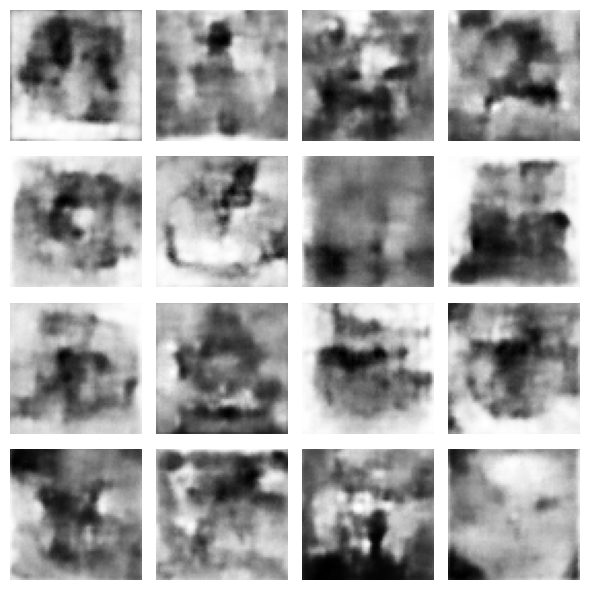

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_new_images(model, n_images=16, image_size=64, device="cpu"):

    model.to(device)
    model.eval()

    latent_dim = 64

    cols = int(np.sqrt(n_images))
    rows = int(np.ceil(n_images / cols))

    fig, ax = plt.subplots(rows, cols, figsize=(6,6))

    with torch.no_grad():

        for i in range(n_images):

            z = torch.randn(1, latent_dim, device=device)

            logits = model.decoder(z)

            images = torch.sigmoid(logits)

            img = images[0,0].cpu()

            r = i // cols
            c = i % cols

            ax[r,c].imshow(img, cmap="gray")
            ax[r,c].axis("off")

    plt.tight_layout()
    plt.show()


generate_new_images(vae, device=device)

## Saving the Model

In [ ]:
save_path = "../saved_models/cnn_vae_03_celeba.pth"

checkpoint = {
    "model_state_dict": vae.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": {
        "latent_dim": 64,
        "input_channels": 1,
        "input_size": 64,
        "base_filters": 64,
        "architecture": "4-layer-CNN"
    }
}

torch.save(checkpoint, save_path)
print(f"Model and config saved successfully to {save_path}")

Model saved successfully


## Loading the Model

In [ ]:
import torch

load_path = "../saved_models/cnn_vae_03_celeba.pth"
checkpoint = torch.load(load_path, map_location=device)

saved_config = checkpoint["config"]
latent_dim = saved_config["latent_dim"]

# Assuming your main VAE class is called 'VAE'
loaded_model = CNNVAE(latent_dim=latent_dim).to(device)

# 4. Load the weights
loaded_model.load_state_dict(checkpoint["model_state_dict"])

# 5. Set to eval mode for inference
loaded_model.eval()

print("Model architecture re-initialized and weights loaded successfully.")
print(f"Config used: {saved_config}")

## Sample from the loaded Model

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_new_images(model, n_images=16, image_size=64, device="cpu"):

    model.to(device)
    model.eval()

    latent_dim = 64

    cols = int(np.sqrt(n_images))
    rows = int(np.ceil(n_images / cols))

    fig, ax = plt.subplots(rows, cols, figsize=(6,6))

    with torch.no_grad():

        for i in range(n_images):

            z = torch.randn(1, latent_dim, device=device)

            logits = model.decoder(z)

            images = torch.sigmoid(logits)

            img = images[0,0].cpu()

            r = i // cols
            c = i % cols

            ax[r,c].imshow(img, cmap="gray")
            ax[r,c].axis("off")

    plt.tight_layout()
    plt.show()
    
generate_new_images(loaded_model, device=device)